# Face Recognition

## 0. Problem Statement
We intend to perform face recognition. Face recognition means that for a given image you can
tell the subject id. Our database of subject is very simple. It has 40 subjects. Below we will
show the needed steps to achieve the goal of the assignment.

## 1. Imports and Utilities

In [330]:
import numpy as np
import matplotlib.pyplot as plt
import os
from time import time
from matplotlib import gridspec
import math

## 2. Data Preparation

In [331]:
class FaceDataset:
    def __init__(self, path='dataset', subjects=40, imgs_per_subject=10):
        self.path = path
        self.imgs, self.D, self.y = [], [], []
        self.subjects = subjects
        self.imgs_per_subject = imgs_per_subject
        self.X_test, self.X_train = [], []
        self.y_test, self.y_train = [], []

    def load_data(self):
        self.imgs = [plt.imread(f'{self.path}/s{i + 1}/{j + 1}.pgm') for i in range(self.subjects) for j in range(self.imgs_per_subject)]
        self.imgs = np.array(self.imgs)

    def flatten_data(self):
        self.D = np.array([self.imgs[i].flatten() for i in range(len(self.imgs))])
        self.y = np.array([i + 1 for i in range(self.subjects) for _ in range(self.imgs_per_subject)])

    def split_train_test(self):
        self.X_test, self.X_train = self.D[0::2], self.D[1::2]
        self.y_test, self.y_train = self.y[0::2], self.y[1::2]
        return (self.X_train, self.y_train), (self.X_test, self.y_test)

    def print_sample(self, samples_number=5):
        samples_number *= self.imgs_per_subject

        plt.figure(figsize=(self.imgs_per_subject, samples_number / 2 * 2.5))

        for i, img in enumerate(self.imgs):
            if i == samples_number:
                break
            plt.subplot(samples_number, self.imgs_per_subject, i + 1)
            plt.imshow(img, cmap="gray")
            plt.axis('off')

        plt.tight_layout()
        plt.show()

face_dataset = FaceDataset()

### 2.1.  Download the Dataset

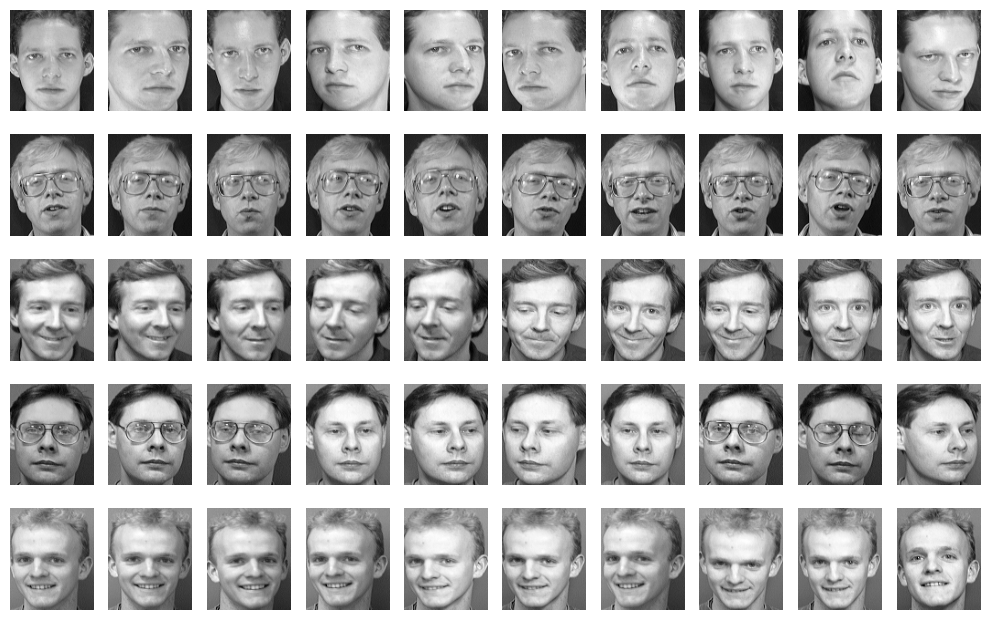

In [332]:
face_dataset.load_data()
face_dataset.print_sample()

### 2.2. Generate the Data Matrix and Label Vector

In [333]:
face_dataset.flatten_data()
print(f"Data Matrix shape: {face_dataset.D.shape}, y shape: {face_dataset.y.shape}")

Data Matrix shape: (400, 10304), y shape: (400,)


### 2.3. Split the Dataset into Training and Test sets

In [334]:
face_dataset.split_train_test()
print(f"Train shape: {face_dataset.X_train.shape}, Test shape: {face_dataset.X_test.shape}")

Train shape: (200, 10304), Test shape: (200, 10304)


In [335]:
X_train = face_dataset.X_train
X_test = face_dataset.X_test
y_train = face_dataset.y_train
y_test = face_dataset.y_test

## 3. PCA Implementation

### 3.0. Pseudocode

* center data by subtracting the mean
* Find directions of maximum variance (principal components)
* Sort components by importantance (eigenvalues)
* Keeping only components needed to achieve certain variance

### 3.1. Compute PCA

In [336]:
class PCA:
    def __init__(self, variance_thresholds=[0.8,0.85,0.9,0.95]):
        self.thresholds = sorted(variance_thresholds)
        self.mean = None
        self.components = None
        self.eigenvalues = None
        self.cumulative_variance = None
        # file to store pca parameters (components,eigenvalues,mean)
        # so that they are computed once for the highest threshold and we use subsets of these components for the lower thresholds
        self.cache_file = 'pca_cache.npz'
        
    def get_pca(self, X):
        # centering the data: by subtracting the mean vector from the data 
        self.mean = np.mean(X, axis=0, dtype=np.float32)
        X_centered = X - self.mean
        
        # computing the covariance matrix
        n_samples = X.shape[0]
        cov = X_centered @ X_centered.T * (1 / n_samples)

        # performing eigenvalue decomposition
        epsilon = 1e-10
        eigen_values, eigen_vectors = np.linalg.eigh(cov)
        eigen_vectors = X_centered.T @ eigen_vectors
        eigen_vectors /= np.linalg.norm(eigen_vectors, axis=0) + epsilon

        # sorting by descending eigenvalue
        i = np.argsort(eigen_values)[::-1]
        return eigen_values[i],eigen_vectors[:,i]
    
    def fit(self, X, is_computed=False):
        # if we have computed and cached the results before just load them
        if is_computed and os.path.exists(self.cache_file):
            cache = np.load(self.cache_file)
            self.eigenvalues = cache['eigenvalues']
            self.components = cache['components']
            self.mean = cache['mean']
        # otherwise compute PCA from scratch
        else:
            start = time()
            eigen_values, eigen_vectors = self.get_pca(X)
            self.eigenvalues = eigen_values.astype(np.float32)
            
            # eigenvalues = variance along each principal component
            # total variance = sum of eigenvalues
            total_variance = np.sum(eigen_values)

            # compute how much variance we keep as we add components
            # using comulative sum
            explained_variance = np.cumsum(eigen_values) / total_variance
            
            # finding how many components we need to keep the maximum requested variance
            max_components = np.argmax(explained_variance >= max(self.thresholds)) + 1 # +1 to convert from 0 based index to component count
            self.components = eigen_vectors[:,:max_components].astype(np.float32)
            
            # saving results to cache file for faster future runs
            np.savez(self.cache_file, 
                    eigenvalues=self.eigenvalues,
                    components=self.components,
                    mean=self.mean)
            
            print(f"PCA computed in {time()-start:.4f}s")
        
        # final calculations needed for all thresholds
        total_variance = np.sum(self.eigenvalues)
        self.cumulative_variance = np.cumsum(self.eigenvalues) / total_variance
        
        return self
    
    def get_components(self, threshold):
        # gets the components needed for specific variance
        n_components = np.argmax(self.cumulative_variance >= threshold) + 1
        return self.components[:, :n_components]
    
    def transform(self, X, threshold):
        # project data onto the principal components
        components = self.get_components(threshold)
        return (X - self.mean) @ components
    
    # reporting dimensionality
    def report_results(self):
        print("PCA dimentionality report")
        print("-"*45)
        print("{:<10} {:<15} {:<20}".format("Threshold","Components","Variance retained"))
        print("-"*45)

        for i in self.thresholds:
            n_comp = np.argmax(self.cumulative_variance >= i) + 1
            var_retained = self.cumulative_variance[n_comp-1]
            print("{:<10.2f} {:<15} {:<20.4f}".format(i,n_comp,var_retained))

### 3.2. Project Data

In [337]:
pca = PCA(variance_thresholds=[0.8,0.85,0.9,0.95])
# computing pca for training data
pca.fit(X_train)

# report dimensionality
pca.report_results()

PCA computed in 0.0603s
PCA dimentionality report
---------------------------------------------
Threshold  Components      Variance retained   
---------------------------------------------
0.80       37              0.8029              
0.85       53              0.8523              
0.90       77              0.9008              
0.95       116             0.9501              


In [338]:
# dictionary to store all reduced datasets
projected_data = {}

# reducing dimensions of both training and test data for each threshold
for i in pca.thresholds:
    X_train_pca = pca.transform(X_train, i)
    X_test_pca = pca.transform(X_test, i)
    projected_data[i] = {
        'train':X_train_pca,
        'test':X_test_pca
    }
    print(f"\nThreshold {i}: Train shape {X_train_pca.shape}, Test shape {X_test_pca.shape}")


Threshold 0.8: Train shape (200, 37), Test shape (200, 37)

Threshold 0.85: Train shape (200, 53), Test shape (200, 53)

Threshold 0.9: Train shape (200, 77), Test shape (200, 77)

Threshold 0.95: Train shape (200, 116), Test shape (200, 116)


### 3.3. Visualization

## 4. Unsupervised Clustering

### 4.1. K-Means Clustering

#### 4.1.1. K-Means Implementation

#### 4.1.2. Evaluation

#### 4.1.3. Analysis

### 4.2. Gaussian Mixture Model Clustering

#### 4.2.1. GMM Implementation

In [593]:
from scipy.stats import multivariate_normal
from sklearn.cluster import KMeans

class GaussianMixtureModels:
    def __init__(self, n_components = 5, max_iter = 100, random_state = 42):
        self.n_components = n_components
        self.max_iter = max_iter
        self.random_state = random_state
        np.random.seed(random_state)

    def fit(self, X_train):
        X_train = np.asarray(X_train)
        self.r = np.zeros((X_train.shape[0], self.n_components))

        self.mixture_weights = np.full((self.n_components,), 1 / self.n_components)

        kmeans = KMeans(n_clusters=self.n_components, random_state=self.random_state).fit(X_train)
        self.means = kmeans.cluster_centers_

        # # Initialize an empty list to store covariances
        # covariances = []

        # # Get the labels assigned by KMeans
        # labels = kmeans.labels_

        # for k in range(self.n_components):
        #     # Select data points assigned to cluster k
        #     cluster_points = X_train[labels == k]

        #     if len(cluster_points) > 1:
        #         # Compute covariance for cluster k
        #         cov = np.cov(cluster_points, rowvar=False)
        #     else:
        #         # If not enough points, fallback to identity
        #         cov = np.eye(X_train.shape[1])

        #     # Regularize slightly to avoid singularities
        #     cov += 1e-6 * np.eye(X_train.shape[1])

        #     covariances.append(cov)

        # self.cov_matrix = np.array(covariances)
        indices = np.random.choice(X_train.shape[0], self.n_components, replace=False)
        self.means = X_train[indices]
        self.cov_matrix = np.array([np.eye(X_train.shape[1]) for _ in range(self.n_components)])

        self._expectation_maximization(X_train)

    def predict(self, X_test):
        tmp_resp = np.zeros((X_train.shape[0], self.n_components))
        for k in range(self.n_components):
            tmp_resp[:, k] = self._compute_normal_distribution(X_test, self.means[k], self.cov_matrix[k])
        numerator = tmp_resp * self.mixture_weights
        denominator = numerator.sum(axis=1)[:, np.newaxis]
        max_k = np.argmax(numerator / denominator, axis=1)
        return max_k


    def _expectation_maximization(self, X_train):
        prev_means = self.means.copy()
        prev_covs = self.cov_matrix.copy()

        for i in range(self.max_iter):
            self._expectation(X_train)
            self._maximization(X_train)

            # Check if the means or covariances have changed significantly
            mean_diff = np.linalg.norm(self.means - prev_means)
            cov_diff = np.linalg.norm(self.cov_matrix - prev_covs)

            if mean_diff < 1e-6 and cov_diff < 1e-6:
                print(f"Converged at iteration {i} ...")
                break  # Stop if the change is small enough
            prev_means = self.means.copy()
            prev_covs = self.cov_matrix.copy()


    def _expectation(self, X_train):
        self._compute_responsibilities_matrix(X_train)

    def _maximization(self, X_train):
        self._compute_mixture_weights()
        self._compute_means(X_train)
        self._compute_cov_matrices(X_train)

    def _compute_normal_distribution(self, x, mean, cov):
        return multivariate_normal(mean=mean, cov=cov).pdf(x)

    def _compute_responsibilities_matrix(self, X_train):
        for k in range(self.n_components):
            self.r[:, k]  = self._compute_normal_distribution(X_train, self.means[k], self.cov_matrix[k])
        numerator = self.r * self.mixture_weights
        denominator = numerator.sum(axis=1)[:, np.newaxis]
        self.r = numerator / denominator

    def _compute_mixture_weights(self):
        N = self.r.shape[0]
        self.mixture_weights = np.sum(self.r, axis=0) / N

    def _compute_means(self, X_train):
        for k in range(self.n_components):
            numerator = np.zeros(X_train.shape[1])
            denominator = 0
            for i, r in enumerate(self.r):
                numerator += r[k] * X_train[i]
                denominator += r[k]
            self.means[k] = numerator / denominator

    def _compute_cov_matrices(self, X_train, epsilon = 1e-6):
        for k in range(self.n_components):
            numerator = np.zeros((X_train.shape[1], X_train.shape[1]))
            denominator = 0
            for i, r in enumerate(self.r):
                diff = X_train[i] - self.means[k]
                numerator += r[k] * np.outer(diff, diff)
                denominator += r[k]
            self.cov_matrix[k] = numerator / denominator + epsilon * np.eye(X_train.shape[1])


#### 4.2.2. Evaluation

In [ ]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # Set before imports

from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler

print("Built-in Implementation:")

k_list = [20, 40, 60]
dim = 61
# for threshold in projected_data:
#     for k in k_list:
#         gm = GaussianMixture(n_components=k, random_state=37).fit(projected_data[threshold]['train'])
#         y_pred = gm.predict(projected_data[threshold]['test'])
#         confusion_matrix = np.zeros((dim, dim))
        
#         for true_label, pred_label in zip(y_test, y_pred):
#             confusion_matrix[true_label, pred_label] += 1

#         row_ind, col_ind = linear_sum_assignment(-confusion_matrix)
#         label_mapping = dict(zip(col_ind, row_ind))
#         y_pred_mapped = [label_mapping[label]  for label in y_pred]
#         accuracy = accuracy_score(y_test, y_pred_mapped)
#         print(f"Accuracy for thershold = {threshold} and k = {k} : {accuracy}")
#     print("-------------------------------------------------------------------------")

print("My Implementation:")


for threshold in projected_data:
    for k in k_list:
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(projected_data[threshold]['train'])
        X_test_scaled = scaler.fit_transform(projected_data[threshold]['test'])

        gmm = GaussianMixtureModels(n_components=k, random_state=37, max_iter=1)
        gmm.fit(X_train_scaled)
        y_pred = gmm.predict(X_test_scaled)

        confusion_matrix = np.zeros((dim, dim))

        for true_label, pred_label in zip(y_test, y_pred):
            confusion_matrix[true_label, pred_label] += 1

        row_ind, col_ind = linear_sum_assignment(-confusion_matrix)
        label_mapping = dict(zip(col_ind, row_ind))
        y_pred_mapped = [label_mapping[label]  for label in y_pred]
        accuracy = accuracy_score(y_test, y_pred_mapped)
        print(f"Accuracy for thershold = {threshold} and k = {k} : {accuracy}")
    print("-------------------------------------------------------------------------")


# scaler = MinMaxScaler()
# X_train_scaled = scaler.fit_transform(projected_data[0.8]['train'])
# X_test_scaled = scaler.fit_transform(projected_data[0.8]['test'])

# gmm = GaussianMixtureModels(n_components=40, random_state=37, max_iter=1)

# gmm.fit(X_train_scaled)
# y_pred = gmm.predict(X_test_scaled)
# print(y_pred)


Built-in Implementation:
My Implementation:
Accuracy for thershold = 0.8 and k = 20 : 0.345
Accuracy for thershold = 0.8 and k = 40 : 0.51
Accuracy for thershold = 0.8 and k = 60 : 0.58
-------------------------------------------------------------------------
Accuracy for thershold = 0.85 and k = 20 : 0.345
Accuracy for thershold = 0.85 and k = 40 : 0.535
Accuracy for thershold = 0.85 and k = 60 : 0.585
-------------------------------------------------------------------------
Accuracy for thershold = 0.9 and k = 20 : 0.325
Accuracy for thershold = 0.9 and k = 40 : 0.53
Accuracy for thershold = 0.9 and k = 60 : 0.58
-------------------------------------------------------------------------
Accuracy for thershold = 0.95 and k = 20 : 0.285
Accuracy for thershold = 0.95 and k = 40 : 0.435
Accuracy for thershold = 0.95 and k = 60 : 0.475
-------------------------------------------------------------------------


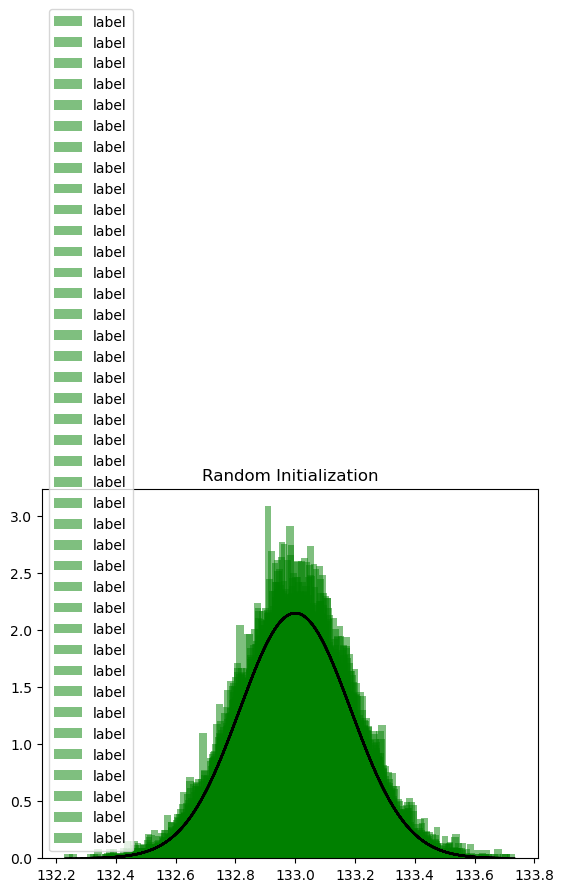

In [568]:
from scipy.stats import norm

def plot_pdf(mu,sigma,label,alpha=0.5,linestyle='k--',density=True,color='green'):
    """
    Plot 1-D data and its PDF curve.

    Parameters
    ----------
    X : array-like, shape (n_samples,)
        The input data.
    """
    # Compute the mean and standard deviation of the data

    # Plot the data
    
    X = norm.rvs(mu, sigma, size=1000)
    
    plt.hist(X, bins=50, density=density, alpha=alpha,label=label,color=color)

    # Plot the PDF
    x = np.linspace(X.min(), X.max(), 1000)
    y = norm.pdf(x, mu, sigma)
    plt.plot(x, y, linestyle)
    
def random_init(n_compenents):
    """Initialize means, weights and variance randomly"""
    pi = np.ones((n_compenents)) / n_compenents
    means = np.random.choice(X_train_scaled.shape[0], n_compenents)
    variances = np.random.random_sample(size=n_compenents)
    for i in range(n_compenents):
        plot_pdf(means[0],variances[0],'label')
    
    plt.title("Random Initialization")
    
    plt.legend()
    plt.show()
random_init(40)

#### 4.2.3. Analysis

## 5. Evaluation

### 5.1. Best K-Means Model

### 5.2. Best GMM Model

### 5.3. Comparison
Compare K-Means vs GMM in this cell

## 6. Autoencoder for Dimensionality Reduction

### 6.1. Autoencoder Implementation

### 6.2. Clustering on Autoencoder Features

### 6.3. Comparison

### 6.4. Visualization